# Exploratory Data Analysis (EDA) - Indonesian Food Recipes

Dataset: `Indonesian_Food_Recipes.csv`

## Daftar Isi
1. Import Library & Load Data
2. Overview Dataset
3. Data Cleaning
4. Analisis Univariat
5. Analisis Bivariat
6. Text Analysis
7. Kesimpulan

## 1. Import Library & Load Data

In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import re
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

# Palet Warna: Merah, Oranye, Kuning
MERAH = '#C0392B'
ORANYE_TUA = '#D35400'
ORANYE = '#E67E22'
ORANYE_MUDA = '#F39C12'
KUNING = '#F1C40F'
KUNING_MUDA = '#F4D03F'

warm_colors = [MERAH, ORANYE_TUA, ORANYE, ORANYE_MUDA, KUNING, KUNING_MUDA]
warm_cmap = mcolors.LinearSegmentedColormap.from_list('warm', [MERAH, ORANYE, KUNING])

# Load Data
df = pd.read_csv('Indonesian_Food_Recipes.csv')
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')

Dataset berhasil dimuat: 14945 baris, 10 kolom


## 2. Overview Dataset

In [251]:
# 5 Baris Pertama Dari Dataset
df.head()

,Title,Ingredients,Steps,Loves,URL,Category,Title Cleaned,Total Ingredients,Ingredients Cleaned,Total Steps
0,Ayam Woku Manado,1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...,1) Cuci bersih ayam dan tiriskan. Lalu peras j...,1,https://cookpad.com/id/resep/4473027-ayam-woku...,ayam,ayam woku manado,14,"ayam kampung potong , jeruk nipis , garam , ku...",7
1,Ayam goreng tulang lunak,1 kg ayam (dipotong sesuai selera jangan kecil...,"1) Haluskan bumbu2nya (BaPut, ketumbar, kemiri...",1,https://cookpad.com/id/resep/4471956-ayam-gore...,ayam,ayam goreng tulang lunak,11,"ayam dipotong , serai , daun jeruk , bawang pu...",5
2,Ayam cabai kawin,1/4 kg ayam--3 buah cabai hijau besar--7 buah ...,1) Panaskan minyak di dalam wajan. Setelah min...,2,https://cookpad.com/id/resep/4473057-ayam-caba...,ayam,ayam cabai kawin,10,"ayam , cabai hijau , cabai merah rawit , bawan...",3
3,Ayam Geprek,250 gr daging ayam (saya pakai fillet)--Secuku...,1) Goreng ayam seperti ayam krispi\n2) Ulek se...,10,https://cookpad.com/id/resep/4473023-ayam-geprek,ayam,ayam geprek,7,"daging ayam fillet , gula garam , tepung ayam ...",3
4,Minyak Ayam,400 gr kulit ayam & lemaknya--8 siung bawang p...,1) Cuci bersih kulit ayam. Sisihkan\n2) Ambil ...,4,https://cookpad.com/id/resep/4427438-minyak-ayam,ayam,minyak ayam,5,"kulit ayam & lemaknya , bawang putih , cincang...",6


In [252]:
# Info Dataset
print('='*60)
print('INFO DATASET')
print('='*60)
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'\nNama kolom:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')
print(f'\nTipe data:')
print(df.dtypes.to_string())

INFO DATASET
Jumlah baris   : 14945
Jumlah kolom   : 10

Nama kolom:
  1. Title
  2. Ingredients
  3. Steps
  4. Loves
  5. URL
  6. Category
  7. Title Cleaned
  8. Total Ingredients
  9. Ingredients Cleaned
  10. Total Steps

Tipe data:
Title                  object
Ingredients            object
Steps                  object
Loves                   int64
URL                    object
Category               object
Title Cleaned          object
Total Ingredients       int64
Ingredients Cleaned    object
Total Steps             int64


In [253]:
# Statistik Deskriptif Kolom Numerik
print('='*60)
print('STATISTIK DESKRIPTIF - KOLOM NUMERIK')
print('='*60)
df.describe()

STATISTIK DESKRIPTIF - KOLOM NUMERIK


,Loves,Total Ingredients,Total Steps
count,14945.000000,14945.000000,14945.000000
mean,11.857812,12.319237,5.388157
std,21.797219,5.013525,2.256049
min,0.000000,1.000000,1.000000
25%,3.000000,9.000000,4.000000
50%,6.000000,12.000000,5.000000
75%,11.000000,15.000000,7.000000
max,939.000000,77.000000,26.000000


In [254]:
# Statistik Deskriptif Kolom Kategorikal
print('='*60)
print('STATISTIK DESKRIPTIF - KOLOM KATEGORIKAL')
print('='*60)
df.describe(include='object')

STATISTIK DESKRIPTIF - KOLOM KATEGORIKAL


,Title,Ingredients,Steps,URL,Category,Title Cleaned,Ingredients Cleaned
count,14945,14945,14945,14945,14945,14925,14945
unique,12468,14939,14940,14945,8,11334,14936
top,Tongseng Kambing,400 gram Daging kambing--3 cup beras--2 buah t...,"1) Panaskan minyak, tumis bawang merah dan cab...",https://cookpad.com/id/resep/4473027-ayam-woku...,udang,tongseng kambing,"daging kambing , beras , tomat , cabe merah ke..."
freq,55,2,2,1,1994,113,2


### 2.1 Analisis Missing Values

In [255]:
# Missing Values per Kolom
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df.sort_values('Jumlah Missing', ascending=False)
print('='*60)
print('MISSING VALUES PER KOLOM:')
print('='*60)
print(missing_df.to_string())
print(f'\nTotal sel missing: {df.isnull().sum().sum()}')
print(f'Total sel keseluruhan: {df.shape[0] * df.shape[1]}')

MISSING VALUES PER KOLOM:
                     Jumlah Missing  Persentase (%)
Title Cleaned                    20            0.13
Title                             0            0.00
Ingredients                       0            0.00
Steps                             0            0.00
Loves                             0            0.00
URL                               0            0.00
Category                          0            0.00
Total Ingredients                 0            0.00
Ingredients Cleaned               0            0.00
Total Steps                       0            0.00

Total sel missing: 20
Total sel keseluruhan: 149450


### 2.2 Cek Duplikasi

In [256]:
# Cek Duplikasi
dup_all = df.duplicated().sum()
dup_title = df.duplicated(subset=['Title']).sum()
dup_url = df.duplicated(subset=['URL']).sum()

print('='*60)
print('ANALISIS DUPLIKASI')
print('='*60)
print(f'Duplikasi seluruh baris : {dup_all} ({dup_all/len(df)*100:.2f}%)')
print(f'Duplikasi berdasarkan Title : {dup_title} ({dup_title/len(df)*100:.2f}%)')
print(f'Duplikasi berdasarkan URL   : {dup_url} ({dup_url/len(df)*100:.2f}%)')

# Contoh Duplikat
if dup_title > 0:
    print(f'\nContoh Title duplikat (5 pertama):')
    dup_titles = df[df.duplicated(subset=['Title'], keep=False)].sort_values('Title')
    print(dup_titles[['Title', 'Category', 'Loves']].head(10).to_string())

ANALISIS DUPLIKASI
Duplikasi seluruh baris : 0 (0.00%)
Duplikasi berdasarkan Title : 2477 (16.57%)
Duplikasi berdasarkan URL   : 0 (0.00%)

Contoh Title duplikat (5 pertama):
                             Title Category  Loves
5925  Asem Asem Buncis Daging Sapi     sapi     36
5825  Asem Asem Buncis Daging Sapi     sapi     15
6650         Asem Asem Daging Sapi     sapi      8
7015         Asem Asem Daging Sapi     sapi      5
6610  Asem asem buncis daging sapi     sapi     40
6817  Asem asem buncis daging sapi     sapi     36
5556         Asem asem daging sapi     sapi      5
6456         Asem asem daging sapi     sapi     29
6471         Asem asem daging sapi     sapi     11
6915         Asem asem daging sapi     sapi      2


## 3. Data Cleaning

In [257]:
print(f'Ukuran dataset SEBELUM cleaning: {df.shape}')
df_clean = df.copy()

# 3.1 Membersihkan Title: Hapus Emoji dan Kata-Kata Noise
# Hapus Emoji
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  
    u"\U0001F300-\U0001F5FF"  
    u"\U0001F680-\U0001F6FF"  
    u"\U0001F1E0-\U0001F1FF"  
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    u"\U0000200d"
    u"\U0000fe0f"
    u"\U00002600-\U000026FF"
    u"\U00002700-\U000027BF"
    "]+", flags=re.UNICODE)

before_emoji = df_clean['Title'].apply(lambda x: bool(emoji_pattern.search(str(x)))).sum()
df_clean['Title'] = df_clean['Title'].apply(lambda x: emoji_pattern.sub('', str(x)).strip())
print(f'Title dengan emoji dibersihkan: {before_emoji} title')

# Hapus Kata-Kata Noise/Promosi dari Title
noise_words = [r'\byummy\b', r'\bsuper\b', r'\bkilat\b', r'\bbangeet\b', r'\bbangettt?\b',
               r'ena+k\s+banget', r'ena{2,}k', r'\bso simple\b', r'\bhomemade\b']
noise_regex = re.compile('|'.join(noise_words), flags=re.IGNORECASE)
before_noise = df_clean['Title'].apply(lambda x: bool(noise_regex.search(str(x)))).sum()
df_clean['Title'] = df_clean['Title'].apply(lambda x: noise_regex.sub('', str(x)))

# Membersihkan Sisa Whitespace Berlebih dan Titik-Titik
df_clean['Title'] = df_clean['Title'].str.replace(r'\.{2,}', '', regex=True)
df_clean['Title'] = df_clean['Title'].str.replace(r'\s{2,}', ' ', regex=True).str.strip()
print(f'Title dengan kata noise dibersihkan: {before_noise} title')

# Update Title Cleaned
df_clean['Title Cleaned'] = df_clean['Title'].str.lower().str.strip()

# 3.2 Hapus Duplikasi Berdasarkan Title (Pertahankan yang Paling Banyak Loves)
df_clean = df_clean.sort_values('Loves', ascending=False)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Title'], keep='first')
print(f'\nSetelah hapus duplikat Title (keep max Loves): {df_clean.shape} — {before - len(df_clean)} baris dihapus')

# 3.3 Handle Missing Values
print(f'\nMissing values sebelum handling:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

critical_cols = ['Title', 'Ingredients', 'Steps', 'Category']
before = len(df_clean)
df_clean = df_clean.dropna(subset=critical_cols)
print(f'\nDrop baris missing pada kolom kritis: {before - len(df_clean)} baris dihapus')

# 3.4 Membersihkan Kolom Numerik
df_clean['Loves'] = pd.to_numeric(df_clean['Loves'], errors='coerce').fillna(0).astype(int)
df_clean['Total Ingredients'] = pd.to_numeric(df_clean['Total Ingredients'], errors='coerce').fillna(0).astype(int)
df_clean['Total Steps'] = pd.to_numeric(df_clean['Total Steps'], errors='coerce').fillna(0).astype(int)

# 3.5 Strip Whitespace pada Kolom String
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()

# 3.6 Standardisasi Kolom Category
df_clean['Category'] = df_clean['Category'].str.lower().str.strip()

# 3.7 Hapus Baris dengan Total Ingredients atau Total Steps = 0
before = len(df_clean)
df_clean = df_clean[(df_clean['Total Ingredients'] > 0) & (df_clean['Total Steps'] > 0)]
print(f'Drop baris dengan 0 ingredients/steps: {before - len(df_clean)} baris dihapus')

# Reset Index
df_clean = df_clean.reset_index(drop=True)

print(f'\n{"="*60}')
print(f'Ukuran dataset SETELAH cleaning: {df_clean.shape}')
print(f'Baris yang dihapus total: {len(df) - len(df_clean)}')
print(f'Missing values tersisa: {df_clean.isnull().sum().sum()}')
print(f'{"="*60}')

Ukuran dataset SEBELUM cleaning: (14945, 10)
Title dengan emoji dibersihkan: 517 title
Title dengan kata noise dibersihkan: 171 title

Setelah hapus duplikat Title (keep max Loves): (12365, 10) — 2580 baris dihapus

Missing values sebelum handling:
Series([], dtype: int64)

Drop baris missing pada kolom kritis: 0 baris dihapus
Drop baris dengan 0 ingredients/steps: 0 baris dihapus

Ukuran dataset SETELAH cleaning: (12365, 10)
Baris yang dihapus total: 2580
Missing values tersisa: 0


In [258]:
# Verifikasi Hasil Cleaning
print('Tipe data setelah cleaning:')
print(df_clean.dtypes)
print(f'\nSample data setelah cleaning:')
df_clean.head()

Tipe data setelah cleaning:
Title                  object
Ingredients            object
Steps                  object
Loves                   int64
URL                    object
Category               object
Title Cleaned          object
Total Ingredients       int64
Ingredients Cleaned    object
Total Steps             int64
dtype: object

Sample data setelah cleaning:


,Title,Ingredients,Steps,Loves,URL,Category,Title Cleaned,Total Ingredients,Ingredients Cleaned,Total Steps
0,Bakso Sapi (Pakai Blender),250 gram daging sapi--35 gram es batu (sekitar...,"1) Siapkan semua bahan, cincang daging sapi ke...",939,https://cookpad.com/id/resep/3431604-bakso-sap...,sapi,bakso sapi (pakai blender),8,"daging sapi , es batu cmx , putih telur , tepu...",10
1,Chilli Tuna Puff,1/2 pack Kulit puff instant saya merk.Edo--Bah...,1) Langkah \n1.Tumis chili tuna chunk dengan m...,516,https://cookpad.com/id/resep/4463240-chilli-tu...,ikan,chilli tuna puff,9,"pack kulit puff instant merkedo , isian , kale...",3
2,Perkedel Tahu Simple,3 buah tahu petak--1 batang daun seledri--2 si...,1) Giling halus bawang merah+bawang putih+ mer...,481,https://cookpad.com/id/resep/4337985-perkedel-...,tahu,perkedel tahu simple,8,"tahu petak , batang daun seledri , bawang puti...",5
3,Orek tempe basah bumbu ulek,1 papan tempe potong sesuai selera--3 buah cab...,1) Goreng tempe yg sdh di potong2 dlm minyak p...,452,https://cookpad.com/id/resep/3989566-orek-temp...,tempe,orek tempe basah bumbu ulek,12,"papan tempe potong , cabe ijo , kecap manis , ...",3
4,Sop Iga Sapi,"1 kg iga sapi, cuci bersih, tiriskan--Secukupn...","1) Didihkan secukupnya air, lalu masukan poton...",375,https://cookpad.com/id/resep/3310336-sop-iga-s...,sapi,sop iga sapi,22,"iga sapi , tiriskan , air didihkan utk rebusan...",4


## 4. Analisis Univariat

### 4.1 Distribusi Kategori Resep

Jumlah kategori unik: 8

Distribusi Kategori:
Category
ikan       1729
telur      1690
udang      1603
tempe      1549
ayam       1499
sapi       1492
kambing    1472
tahu       1331


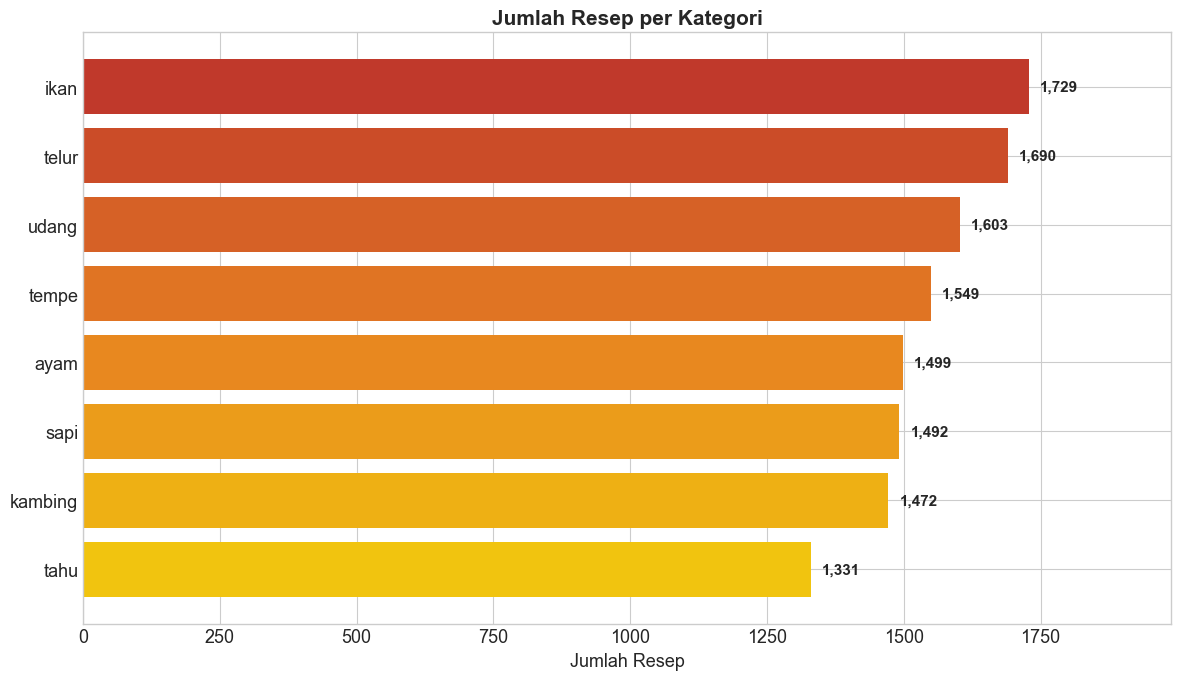

In [259]:
# Distribusi Kategori
cat_counts = df_clean['Category'].value_counts()
print(f'Jumlah kategori unik: {df_clean["Category"].nunique()}')
print(f'\nDistribusi Kategori:')
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 7))

# Bar Chart
n = len(cat_counts)
colors = [warm_cmap(i / max(n - 1, 1)) for i in range(n)]
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1])
ax.set_xlabel('Jumlah Resep')
ax.set_title('Jumlah Resep per Kategori')

# Label
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, cat_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('01_distribusi_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Distribusi Loves (Popularitas)

Statistik Loves (Popularitas):
count    12365.000000
mean        12.568459
std         23.399325
min          0.000000
25%          3.000000
50%          6.000000
75%         12.000000
max        939.000000
Name: Loves, dtype: float64


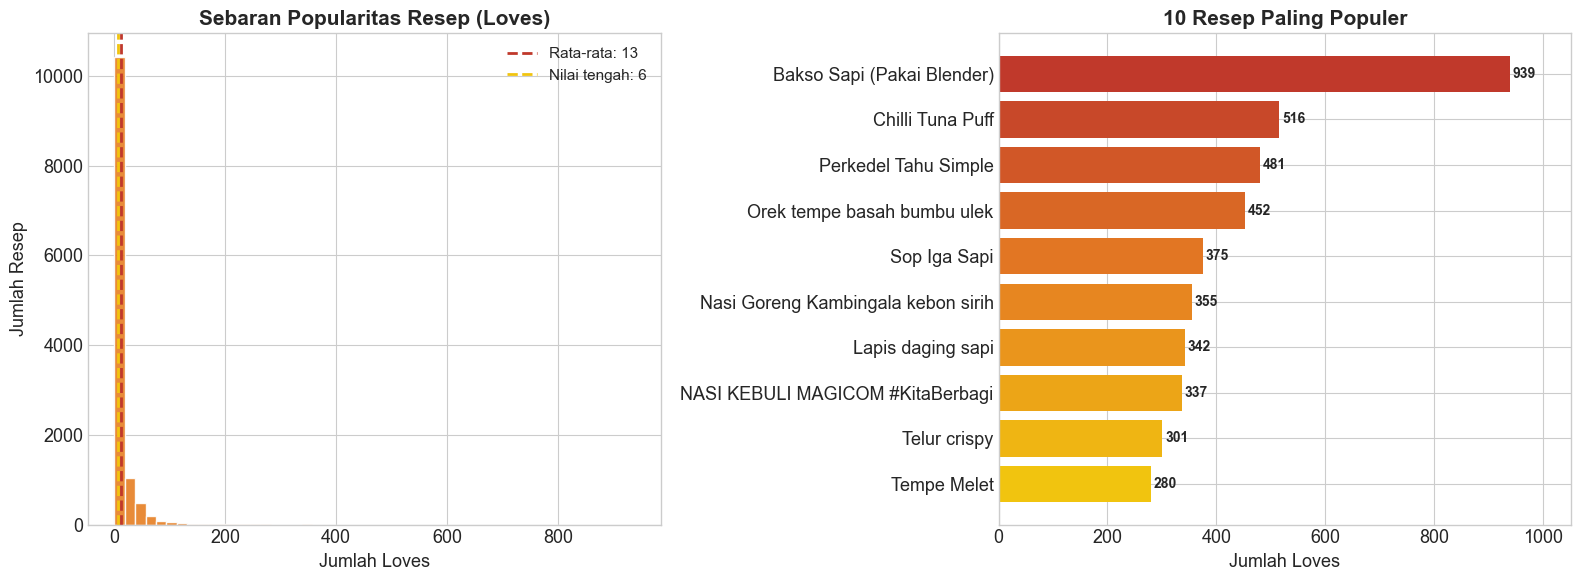

In [260]:
# Statistik Loves
print('Statistik Loves (Popularitas):')
print(df_clean['Loves'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram Loves
axes[0].hist(df_clean['Loves'], bins=50, color=ORANYE, edgecolor='white', alpha=0.9)
axes[0].set_xlabel('Jumlah Loves')
axes[0].set_ylabel('Jumlah Resep')
axes[0].set_title('Sebaran Popularitas Resep (Loves)')
axes[0].axvline(df_clean['Loves'].mean(), color=MERAH, linestyle='--', linewidth=2,
                label=f'Rata-rata: {df_clean["Loves"].mean():.0f}')
axes[0].axvline(df_clean['Loves'].median(), color=KUNING, linestyle='--', linewidth=2,
                label=f'Nilai tengah: {df_clean["Loves"].median():.0f}')
axes[0].legend(fontsize=11)

# Top 10 Resep Paling Populer
top10 = df_clean.nlargest(10, 'Loves')[['Title', 'Loves']].reset_index(drop=True)
colors_top = [warm_cmap(i / 9) for i in range(10)]
bars = axes[1].barh(top10['Title'][::-1], top10['Loves'][::-1], color=colors_top[::-1])
axes[1].set_xlabel('Jumlah Loves')
axes[1].set_title('10 Resep Paling Populer')
for bar, val in zip(bars, top10['Loves'][::-1]):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
                 va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, top10['Loves'].max() * 1.12)

plt.tight_layout()
plt.savefig('02_distribusi_loves.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Distribusi Total Ingredients

Statistik Jumlah Bahan per Resep:
count    12365.000000
mean        12.272382
std          5.011719
min          1.000000
25%          9.000000
50%         12.000000
75%         15.000000
max         77.000000
Name: Total Ingredients, dtype: float64


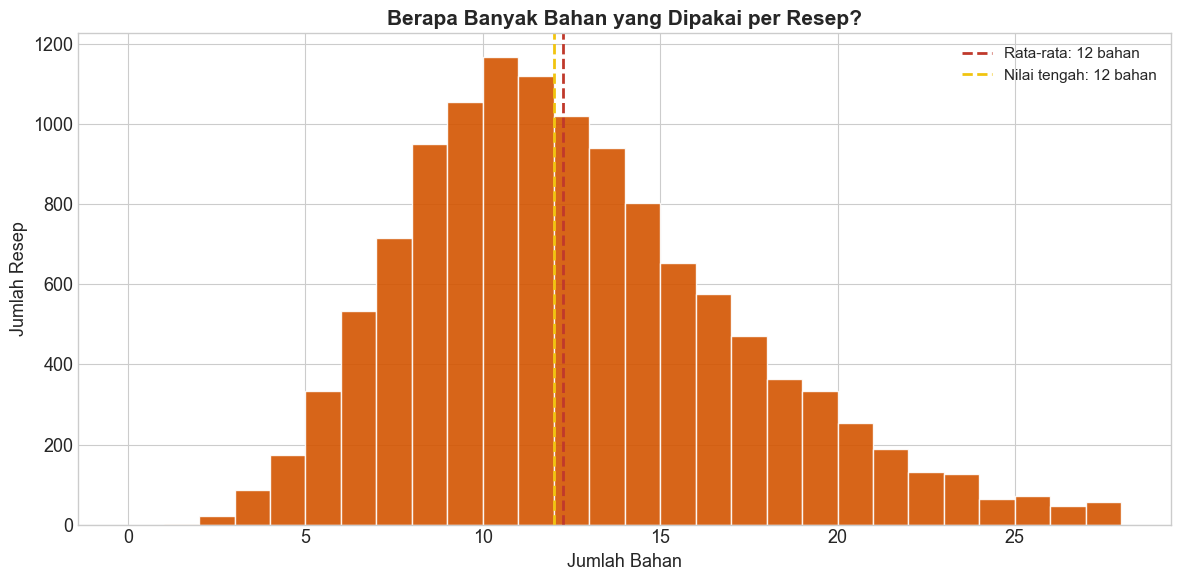

In [261]:
print('Statistik Jumlah Bahan per Resep:')
print(df_clean['Total Ingredients'].describe())

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram Jumlah Bahan
bins = range(0, df_clean['Total Ingredients'].quantile(0.99).astype(int) + 2)
ax.hist(df_clean['Total Ingredients'], bins=bins, color=ORANYE_TUA, edgecolor='white', alpha=0.9)
ax.set_xlabel('Jumlah Bahan')
ax.set_ylabel('Jumlah Resep')
ax.set_title('Berapa Banyak Bahan yang Dipakai per Resep?')
ax.axvline(df_clean['Total Ingredients'].mean(), color=MERAH, linestyle='--', linewidth=2,
           label=f'Rata-rata: {df_clean["Total Ingredients"].mean():.0f} bahan')
ax.axvline(df_clean['Total Ingredients'].median(), color=KUNING, linestyle='--', linewidth=2,
           label=f'Nilai tengah: {df_clean["Total Ingredients"].median():.0f} bahan')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('03_distribusi_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Distribusi Total Steps

Statistik Jumlah Langkah per Resep:
count    12365.000000
mean         5.421108
std          2.274553
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         25.000000
Name: Total Steps, dtype: float64


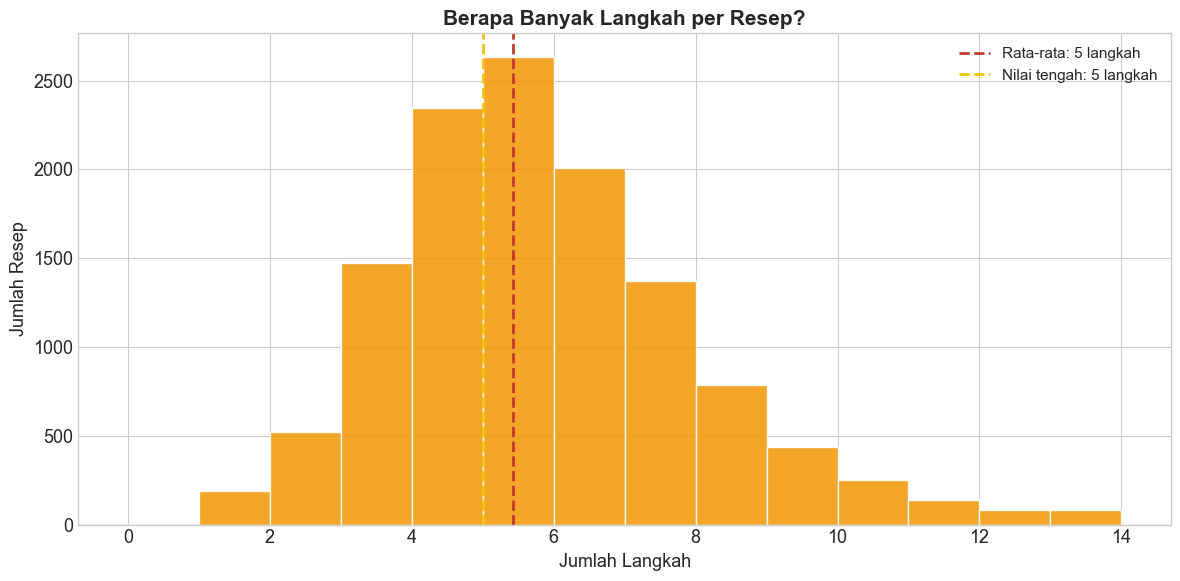

In [262]:
print('Statistik Jumlah Langkah per Resep:')
print(df_clean['Total Steps'].describe())

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram Jumlah Langkah
bins = range(0, df_clean['Total Steps'].quantile(0.99).astype(int) + 2)
ax.hist(df_clean['Total Steps'], bins=bins, color=ORANYE_MUDA, edgecolor='white', alpha=0.9)
ax.set_xlabel('Jumlah Langkah')
ax.set_ylabel('Jumlah Resep')
ax.set_title('Berapa Banyak Langkah per Resep?')
ax.axvline(df_clean['Total Steps'].mean(), color=MERAH, linestyle='--', linewidth=2,
           label=f'Rata-rata: {df_clean["Total Steps"].mean():.0f} langkah')
ax.axvline(df_clean['Total Steps'].median(), color=KUNING, linestyle='--', linewidth=2,
           label=f'Nilai tengah: {df_clean["Total Steps"].median():.0f} langkah')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('04_distribusi_steps.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Deteksi & Analisis Outlier

DETEKSI OUTLIER (IQR Method)
Loves:
  Q1=3.0, Q3=12.0, IQR=9.0
  Batas bawah=-10.5, Batas atas=25.5
  Jumlah outlier: 1464 (11.84%)

Total Ingredients:
  Q1=9.0, Q3=15.0, IQR=6.0
  Batas bawah=0.0, Batas atas=24.0
  Jumlah outlier: 269 (2.18%)

Total Steps:
  Q1=4.0, Q3=7.0, IQR=3.0
  Batas bawah=-0.5, Batas atas=11.5
  Jumlah outlier: 215 (1.74%)



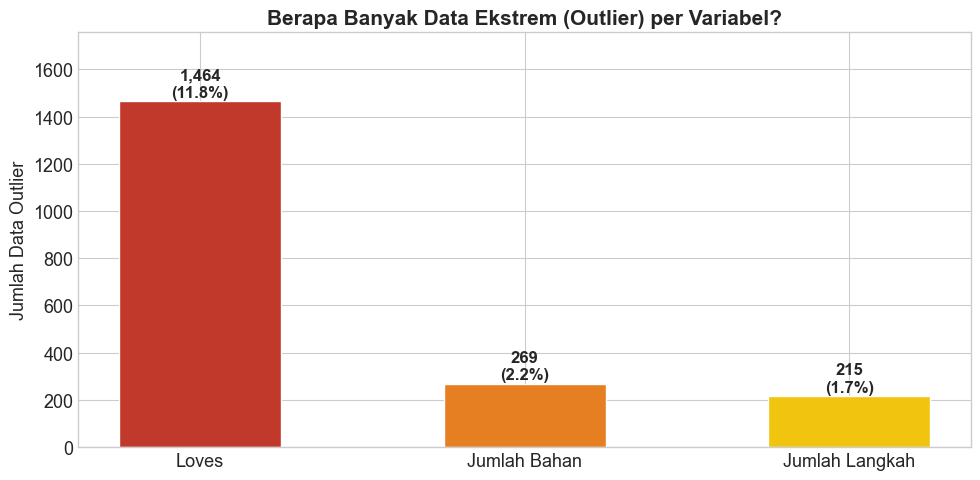

In [263]:
# Deteksi Outlier dengan IQR Method
def detect_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name}:')
    print(f'  Q1={Q1}, Q3={Q3}, IQR={IQR}')
    print(f'  Batas bawah={lower}, Batas atas={upper}')
    print(f'  Jumlah outlier: {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)')
    print()
    return outliers

print('='*60)
print('DETEKSI OUTLIER (IQR Method)')
print('='*60)
out_loves = detect_outliers_iqr(df_clean['Loves'], 'Loves')
out_ingr = detect_outliers_iqr(df_clean['Total Ingredients'], 'Total Ingredients')
out_steps = detect_outliers_iqr(df_clean['Total Steps'], 'Total Steps')

# Visualisasi: Bar Chart Jumlah Outlier per Variabel
fig, ax = plt.subplots(figsize=(10, 5))

outlier_data = {
    'Loves': len(out_loves),
    'Jumlah Bahan': len(out_ingr),
    'Jumlah Langkah': len(out_steps)
}
bars = ax.bar(outlier_data.keys(), outlier_data.values(),
              color=[MERAH, ORANYE, KUNING], edgecolor='white', width=0.5)
ax.set_ylabel('Jumlah Data Outlier')
ax.set_title('Berapa Banyak Data Ekstrem (Outlier) per Variabel?')

for bar, val in zip(bars, outlier_data.values()):
    pct = val / len(df_clean) * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 20,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, max(outlier_data.values()) * 1.2)
plt.tight_layout()
plt.savefig('05_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analisis Bivariat

### 5.1 Korelasi antar Variabel Numerik

Matriks Korelasi:
                    Loves  Total Ingredients  Total Steps
Loves              1.0000             0.0849       0.0130
Total Ingredients  0.0849             1.0000       0.2092
Total Steps        0.0130             0.2092       1.0000


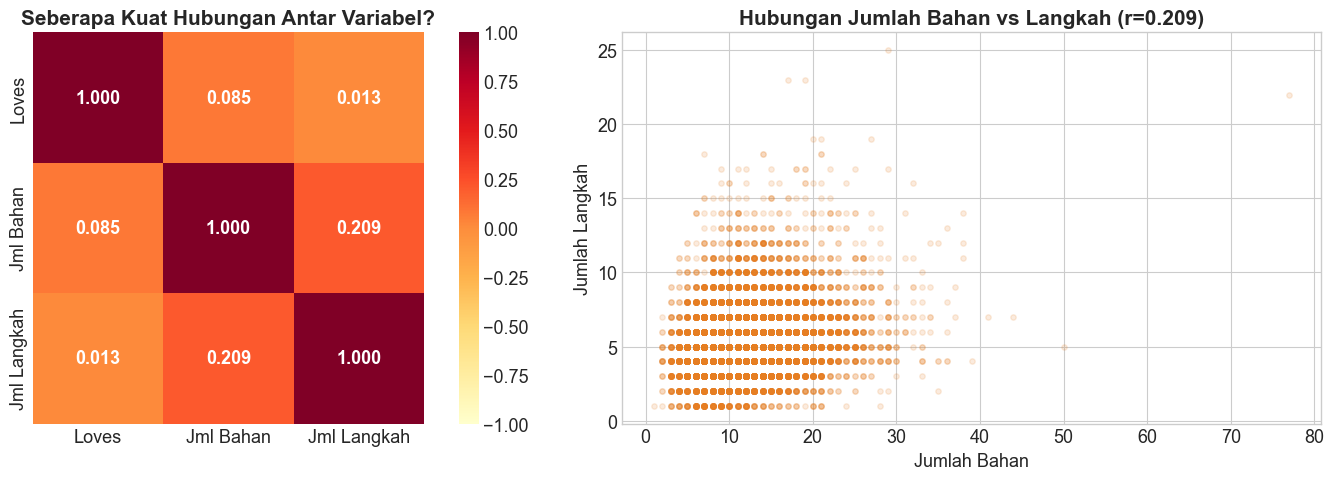

In [264]:
# Korelasi
numeric_cols = ['Loves', 'Total Ingredients', 'Total Steps']
corr = df_clean[numeric_cols].corr()
print('Matriks Korelasi:')
print(corr.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(corr, annot=True, cmap='YlOrRd', fmt='.3f',
            square=True, ax=axes[0], vmin=-1, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'},
            xticklabels=['Loves', 'Jml Bahan', 'Jml Langkah'],
            yticklabels=['Loves', 'Jml Bahan', 'Jml Langkah'])
axes[0].set_title('Seberapa Kuat Hubungan Antar Variabel?')

# Scatter: Total Ingredients vs Total Steps
axes[1].scatter(df_clean['Total Ingredients'], df_clean['Total Steps'],
                alpha=0.15, s=15, color=ORANYE)
axes[1].set_xlabel('Jumlah Bahan')
axes[1].set_ylabel('Jumlah Langkah')
r_val = corr.loc['Total Ingredients', 'Total Steps']
axes[1].set_title(f'Hubungan Jumlah Bahan vs Langkah (r={r_val:.3f})')

plt.tight_layout()
plt.savefig('06_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Loves per Kategori

Statistik per Kategori:
          jumlah_resep  mean_loves  median_loves  total_loves  mean_ingredients  mean_steps
Category                                                                                   
ikan              1729       10.89           6.0        18834             12.45        5.42
telur             1690       12.75           6.0        21552              9.93        5.01
udang             1603       11.19           6.0        17938             11.05        5.27
tempe             1549       12.45           6.0        19281             11.23        5.29
ayam              1499       12.44           6.0        18648             13.42        5.79
sapi              1492       16.97           8.0        25324             13.85        5.71
kambing           1472       12.81           6.0        18855             15.25        5.57
tahu              1331       11.25           6.0        14977             11.35        5.39


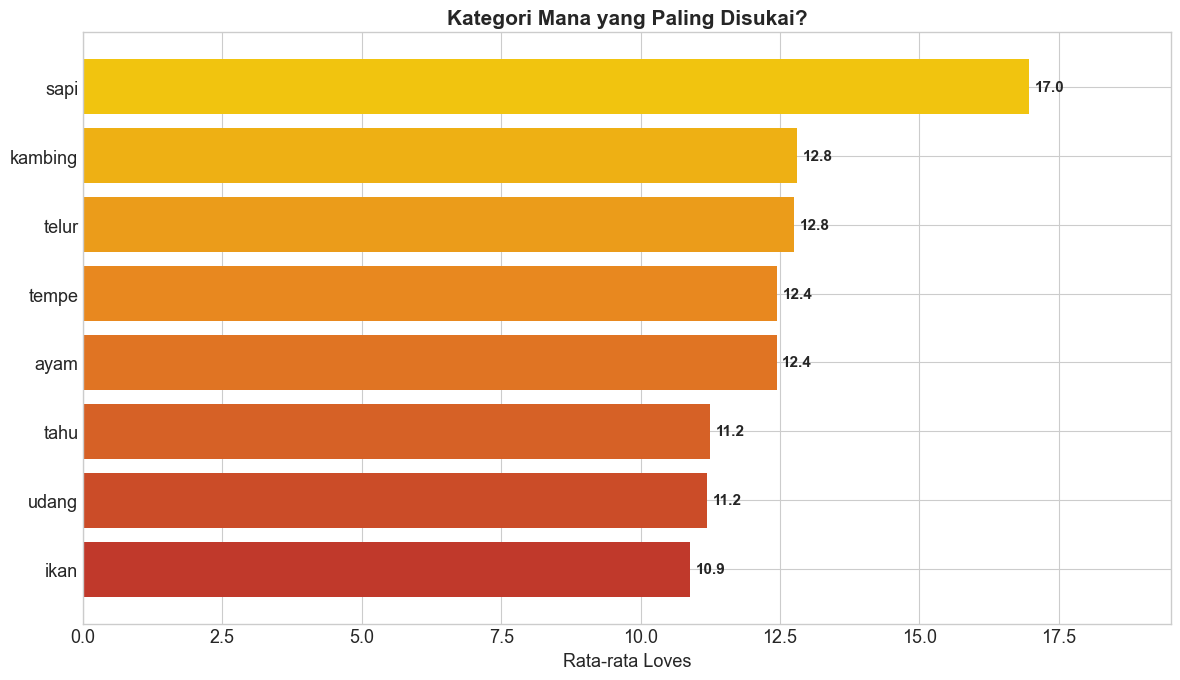

In [265]:
# Rata-rata Loves per Kategori
cat_stats = df_clean.groupby('Category').agg(
    jumlah_resep=('Title', 'count'),
    mean_loves=('Loves', 'mean'),
    median_loves=('Loves', 'median'),
    total_loves=('Loves', 'sum'),
    mean_ingredients=('Total Ingredients', 'mean'),
    mean_steps=('Total Steps', 'mean')
).round(2).sort_values('jumlah_resep', ascending=False)

print('Statistik per Kategori:')
print(cat_stats.to_string())

# Bar chart: Rata-rata Loves per Kategori
cat_by_loves = cat_stats.sort_values('mean_loves', ascending=True)
n = len(cat_by_loves)
colors = [warm_cmap(i / max(n - 1, 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(cat_by_loves.index, cat_by_loves['mean_loves'], color=colors)
ax.set_xlabel('Rata-rata Loves')
ax.set_title('Kategori Mana yang Paling Disukai?')

for bar, val in zip(bars, cat_by_loves['mean_loves']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, cat_by_loves['mean_loves'].max() * 1.15)
plt.tight_layout()
plt.savefig('07_loves_per_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Kompleksitas Resep per Kategori

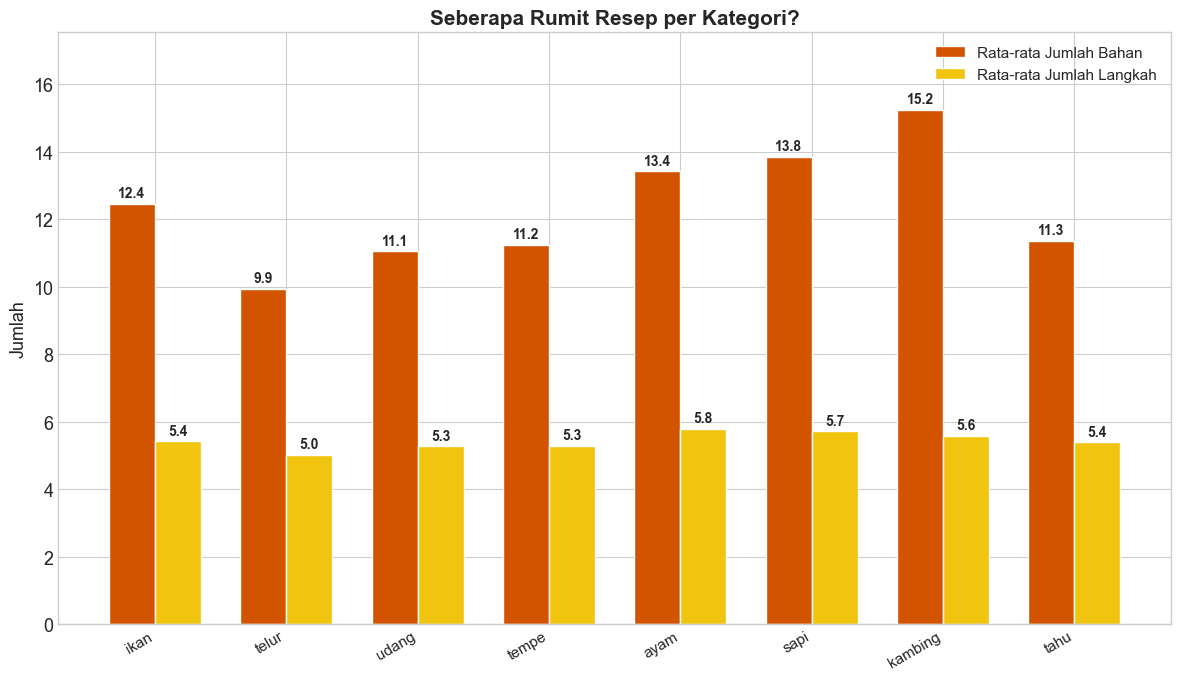

In [266]:
# Kompleksitas Resep per Kategori: Grouped Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))

categories = cat_stats.index.tolist()
x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, cat_stats['mean_ingredients'], width,
               label='Rata-rata Jumlah Bahan', color=ORANYE_TUA, edgecolor='white')
bars2 = ax.bar(x + width/2, cat_stats['mean_steps'], width,
               label='Rata-rata Jumlah Langkah', color=KUNING, edgecolor='white')

# Label
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=30, ha='right', fontsize=11)
ax.set_ylabel('Jumlah')
ax.set_title('Seberapa Rumit Resep per Kategori?')
ax.legend(fontsize=11)
ax.set_ylim(0, cat_stats['mean_ingredients'].max() * 1.15)

plt.tight_layout()
plt.savefig('08_kompleksitas_per_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Text Analysis

### 6.1 Bahan Paling Sering Digunakan

Top 30 Bahan Paling Sering Digunakan:
   1. bawang putih: 9200
   2. garam: 8539
   3. bawang merah: 7173
   4. air: 3596
   5. gula: 2762
   6. jahe: 2542
   7. daun salam: 2491
   8. kecap manis: 2230
   9. bumbu halus: 2230
  10. kemiri: 2126
  11. daun jeruk: 2041
  12. tomat: 2018
  13. kunyit: 1953
  14. lada: 1940
  15. minyak goreng: 1816
  16. lengkuas: 1742
  17. cabe rawit: 1740
  18. penyedap: 1607
  19. bawang bombai: 1564
  20. cabe merah: 1557
  21. telur: 1525
  22. serai: 1463
  23. merica: 1433
  24. ketumbar: 1347
  25. gula pasir: 1276
  26. merica bubuk: 939
  27. bumbu: 860
  28. udang: 850
  29. daun bawang: 828
  30. wortel: 811


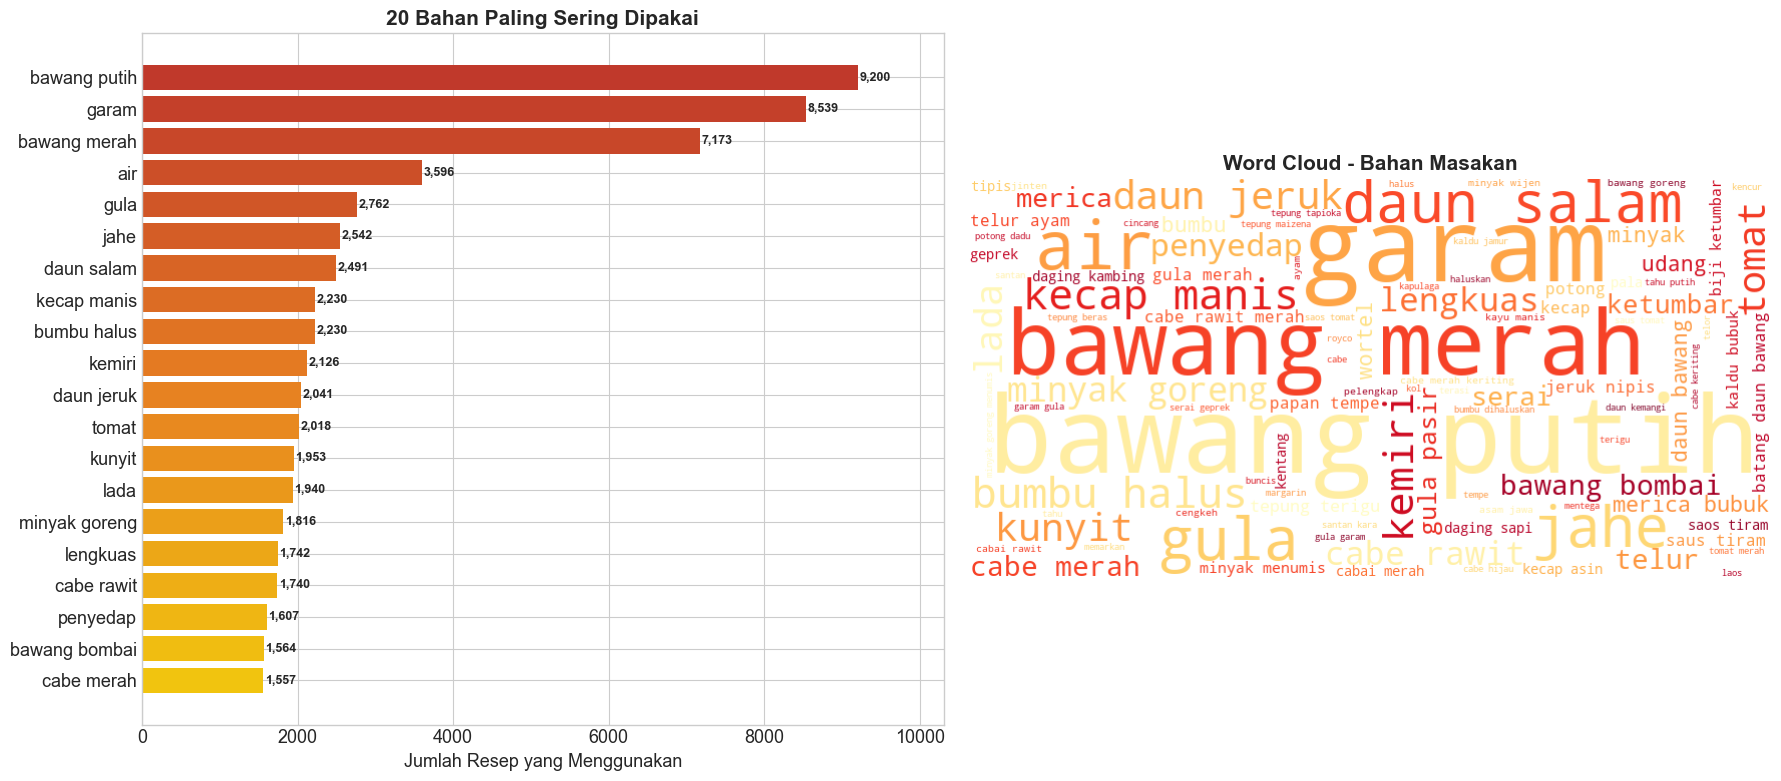

In [267]:
# Analisis Bahan yang Paling Sering Digunakan
all_ingredients = []
for ing in df_clean['Ingredients Cleaned'].dropna():
    items = [i.strip() for i in str(ing).split(',') if i.strip()]
    all_ingredients.extend(items)

ing_counter = Counter(all_ingredients)
top30_ing = ing_counter.most_common(30)

print('Top 30 Bahan Paling Sering Digunakan:')
for i, (ing, count) in enumerate(top30_ing, 1):
    print(f'  {i:2d}. {ing}: {count}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar Chart Top 20 bahan
top20_ing = top30_ing[:20]
ing_names = [x[0] for x in top20_ing]
ing_counts = [x[1] for x in top20_ing]
colors = [warm_cmap(i / 19) for i in range(20)]

bars = axes[0].barh(ing_names[::-1], ing_counts[::-1], color=colors[::-1])
axes[0].set_xlabel('Jumlah Resep yang Menggunakan')
axes[0].set_title('20 Bahan Paling Sering Dipakai')
for bar, val in zip(bars, ing_counts[::-1]):
    axes[0].text(val + 20, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, max(ing_counts) * 1.12)

# Word Cloud Bahan
ing_freq = dict(ing_counter.most_common(100))
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='YlOrRd', max_words=100).generate_from_frequencies(ing_freq)
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Bahan Masakan')

plt.tight_layout()
plt.savefig('09_top_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Word Cloud Judul Resep

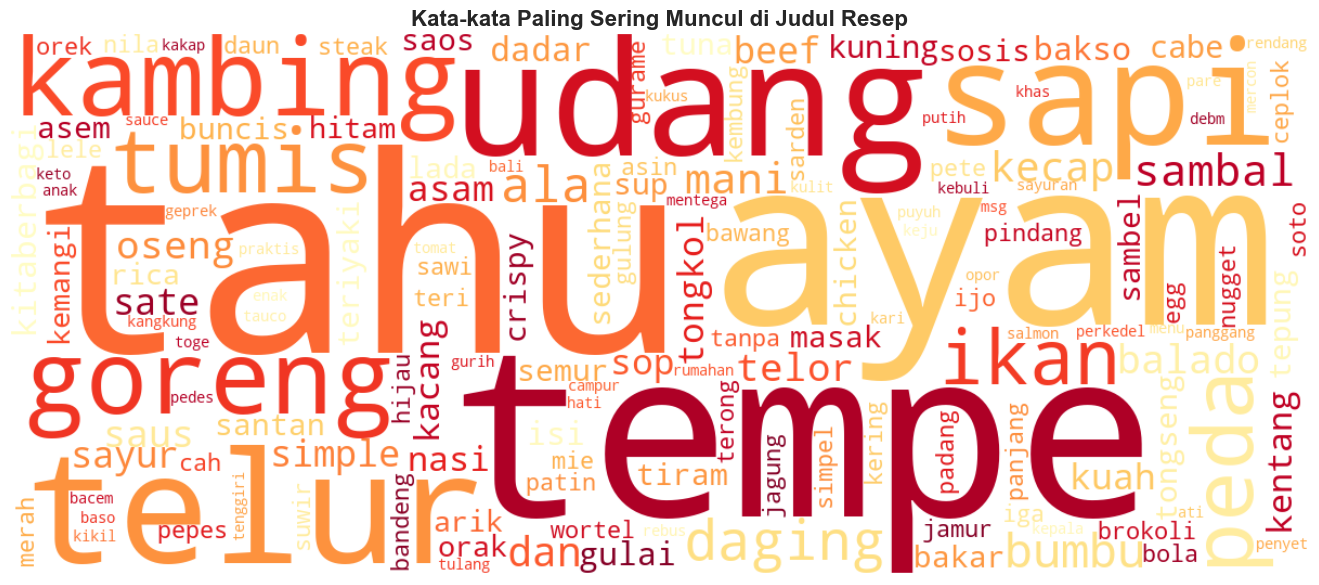

Top 20 Kata dalam Judul Resep:
   1. tahu: 1793
   2. ayam: 1604
   3. tempe: 1550
   4. udang: 1507
   5. telur: 1414
   6. sapi: 1216
   7. kambing: 1044
   8. goreng: 997
   9. tumis: 869
  10. ikan: 774
  11. pedas: 764
  12. daging: 743
  13. bumbu: 545
  14. sambal: 478
  15. manis: 452
  16. kecap: 408
  17. balado: 389
  18. telor: 352
  19. saus: 349
  20. oseng: 327


In [268]:
# Word Cloud dari Title Cleaned
title_text = ' '.join(df_clean['Title Cleaned'].dropna().astype(str).tolist())

wc_title = WordCloud(width=1200, height=500, background_color='white',
                     colormap='YlOrRd', max_words=150,
                     collocations=False).generate(title_text)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_title, interpolation='bilinear')
ax.axis('off')
ax.set_title('Kata-kata Paling Sering Muncul di Judul Resep', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('10_wordcloud_titles.png', dpi=150, bbox_inches='tight')
plt.show()

# Top Kata dalam Judul
title_words = title_text.lower().split()
stopwords_id = {'dan', 'atau', 'yang', 'di', 'ke', 'dari', 'untuk', 'dengan', 'ala', 'khas', 'nya', 'by'}
title_words_filtered = [w for w in title_words if w not in stopwords_id and len(w) > 2]
word_counts = Counter(title_words_filtered).most_common(20)
print('Top 20 Kata dalam Judul Resep:')
for i, (word, count) in enumerate(word_counts, 1):
    print(f'  {i:2d}. {word}: {count}')

### 6.3 Panjang Resep (Karakter dalam Steps)

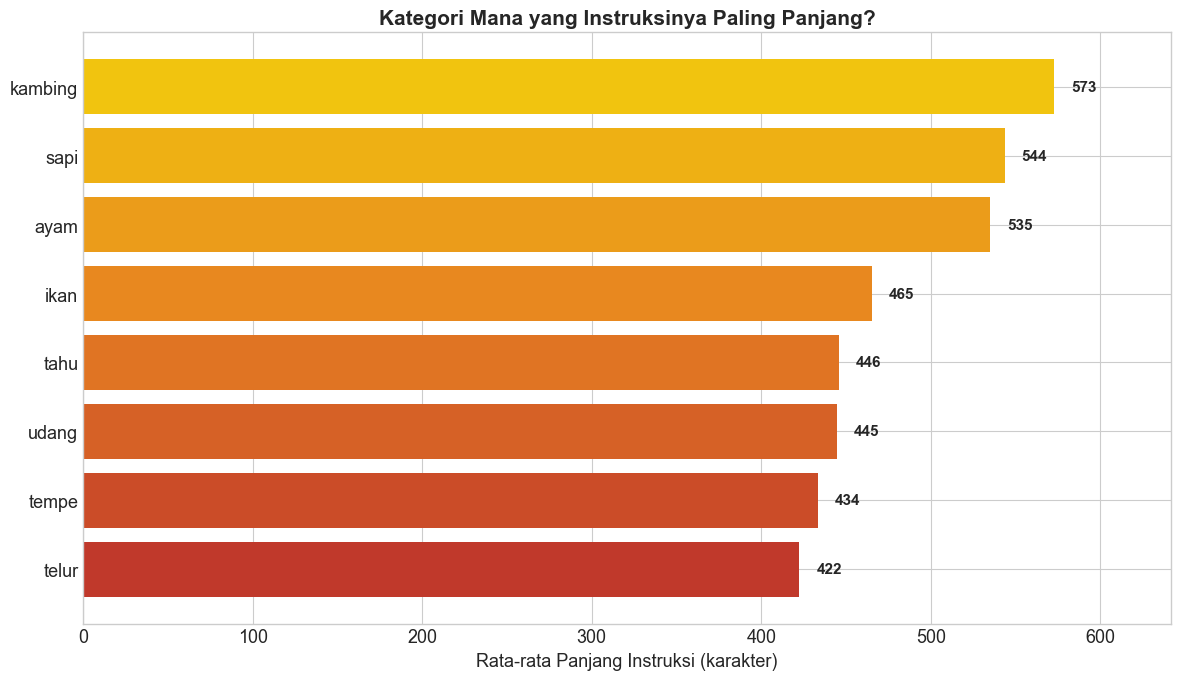

In [269]:
# Analisis Panjang Instruksi per Kategori
df_clean['steps_length'] = df_clean['Steps'].astype(str).apply(len)
df_clean['ingredients_length'] = df_clean['Ingredients'].astype(str).apply(len)

# Rata-rata Panjang Instruksi per Kategori
avg_length = df_clean.groupby('Category')['steps_length'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

n = len(avg_length)
colors = [warm_cmap(i / max(n - 1, 1)) for i in range(n)]
bars = ax.barh(avg_length.index, avg_length.values, color=colors)
ax.set_xlabel('Rata-rata Panjang Instruksi (karakter)')
ax.set_title('Kategori Mana yang Instruksinya Paling Panjang?')

for bar, val in zip(bars, avg_length.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, avg_length.max() * 1.12)
plt.tight_layout()
plt.savefig('11_panjang_resep.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Kesimpulan & Ringkasan

In [270]:
# Drop Kolom Tambahan yang Dibuat Saat Analisis
df_clean = df_clean.drop(columns=['steps_length', 'ingredients_length'], errors='ignore')
print(f'Kolom final: {list(df_clean.columns)}')
print(f'Shape final: {df_clean.shape}')

Kolom final: ['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'Category', 'Title Cleaned', 'Total Ingredients', 'Ingredients Cleaned', 'Total Steps']
Shape final: (12365, 10)


In [271]:
print('='*60)
print('RINGKASAN EDA - Indonesian Food Recipes')
print('='*60)

print(f'''
1. OVERVIEW DATASET:
   - Dataset awal: {len(df)} baris, {df.shape[1]} kolom
   - Dataset setelah cleaning: {len(df_clean)} baris
   - Baris yang dihapus: {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)

2. DATA CLEANING YANG DILAKUKAN:
   - Menghapus baris duplikat (berdasarkan seluruh kolom & URL)
   - Menghapus baris dengan missing values pada kolom kritis (Title, Ingredients, Steps, Category)
   - Konversi tipe data numerik (Loves, Total Ingredients, Total Steps)
   - Standardisasi teks (strip whitespace, lowercase Category)
   - Menghapus baris dengan 0 ingredients atau 0 steps

3. TEMUAN UTAMA:
   - Jumlah kategori unik: {df_clean['Category'].nunique()}
   - Kategori terbanyak: {cat_stats.index[0]} ({cat_stats['jumlah_resep'].iloc[0]} resep)
   - Rata-rata Loves: {df_clean['Loves'].mean():.1f} (median: {df_clean['Loves'].median():.0f})
   - Rata-rata bahan per resep: {df_clean['Total Ingredients'].mean():.1f}
   - Rata-rata langkah per resep: {df_clean['Total Steps'].mean():.1f}
   - Distribusi Loves sangat right-skewed (skewness: {df_clean['Loves'].skew():.2f})
   - Korelasi positif antara Total Ingredients dan Total Steps

4. INSIGHT:
   - Sebagian besar resep memiliki Loves rendah (distribusi right-skewed)
   - Bahan yang paling sering digunakan: garam, bawang putih, bawang merah, gula
   - Resep sederhana (sedikit bahan & langkah) mendominasi dataset
''')

# Simpan Dataset yang Sudah Bersih
df_clean.to_csv('Indonesian_Food_Recipes_Cleaned.csv', index=False)
print('Dataset bersih disimpan ke: Indonesian_Food_Recipes_Cleaned.csv')

RINGKASAN EDA - Indonesian Food Recipes

1. OVERVIEW DATASET:
   - Dataset awal: 14945 baris, 10 kolom
   - Dataset setelah cleaning: 12365 baris
   - Baris yang dihapus: 2580 (17.3%)

2. DATA CLEANING YANG DILAKUKAN:
   - Menghapus baris duplikat (berdasarkan seluruh kolom & URL)
   - Menghapus baris dengan missing values pada kolom kritis (Title, Ingredients, Steps, Category)
   - Konversi tipe data numerik (Loves, Total Ingredients, Total Steps)
   - Standardisasi teks (strip whitespace, lowercase Category)
   - Menghapus baris dengan 0 ingredients atau 0 steps

3. TEMUAN UTAMA:
   - Jumlah kategori unik: 8
   - Kategori terbanyak: ikan (1729 resep)
   - Rata-rata Loves: 12.6 (median: 6)
   - Rata-rata bahan per resep: 12.3
   - Rata-rata langkah per resep: 5.4
   - Distribusi Loves sangat right-skewed (skewness: 10.95)
   - Korelasi positif antara Total Ingredients dan Total Steps

4. INSIGHT:
   - Sebagian besar resep memiliki Loves rendah (distribusi right-skewed)
   - Bahan yang